In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

In [3]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Dataset overview
The dataset contains information about loan applicants including their demographic details, financial status, and loan-related attributes.

- total records: 32581
- features include age, income, intent,loan amount, interest rate and cradit history
- target variable: **lone_status** (0= Not Approved, 1 = Approved)

the dataset contains both numeric and non-numeric features, making it sutable for classification tasks 

In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Data cleaning

- Missing values were identified in:
  - `person_emp_length`
  - `loan_int_rate`

In [6]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28638 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  28638 non-null  int64  
 1   person_income               28638 non-null  int64  
 2   person_home_ownership       28638 non-null  object 
 3   person_emp_length           28638 non-null  float64
 4   loan_intent                 28638 non-null  object 
 5   loan_grade                  28638 non-null  object 
 6   loan_amnt                   28638 non-null  int64  
 7   loan_int_rate               28638 non-null  float64
 8   loan_status                 28638 non-null  int64  
 9   loan_percent_income         28638 non-null  float64
 10  cb_person_default_on_file   28638 non-null  object 
 11  cb_person_cred_hist_length  28638 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.8+ MB


After removing missing valuse in `person_emp_length` and`loan_int_rate` we were left with 28638 rows 

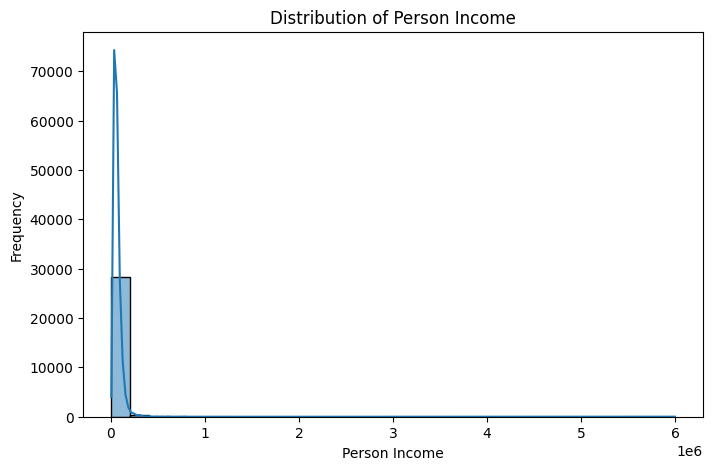

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=30, kde=True)
plt.title('Distribution of Person Income')
plt.xlabel('Person Income')
plt.ylabel('Frequency')
plt.show()

- Outliers were present in `person_income`

In [15]:
df = df[df['person_income'] < df['person_income'].quantile(0.99)]

Extreme income values (top 1%) were removed

### Distribution of Person Income

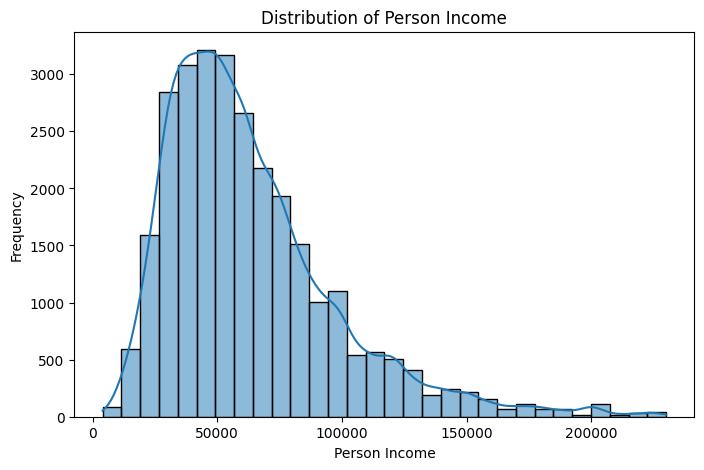

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['person_income'], bins=30, kde=True)
plt.title('Distribution of Person Income')
plt.xlabel('Person Income')
plt.ylabel('Frequency')
plt.show()

This distribution is highly right-skewed
- most applicats fall in low to mid income range
- few applicants fall in high income range

This indicates income inequlity among applicants.

### Distribution of Loan Amount

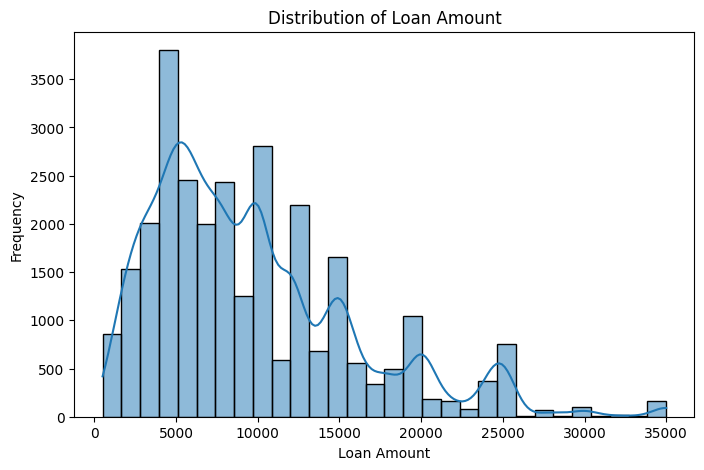

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

This distribution is slightly right-skewed
- Loan amounts are concentrated rated in lower range.
- Few applicants apply for high loans

This suggest borrowers prefers smaller loan amount

### Distribution of Loan Interest Rate

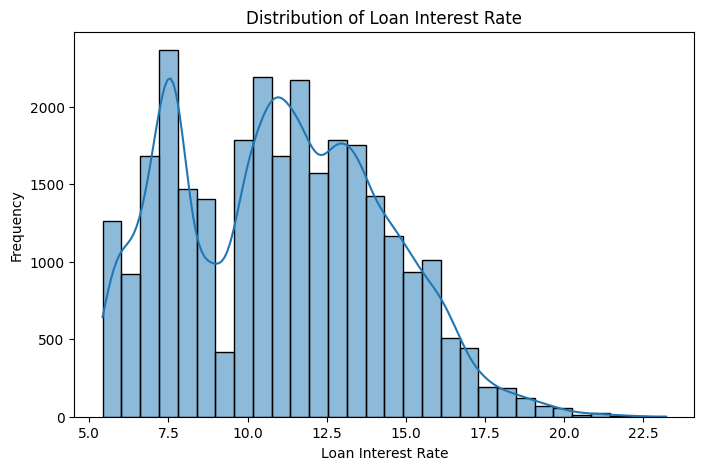

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['loan_int_rate'], bins=30, kde=True)
plt.title('Distribution of Loan Interest Rate')
plt.xlabel('Loan Interest Rate')
plt.ylabel('Frequency')
plt.show()

The distribution is slightly right-sked
- Most interest rates lie between 7% to 15%
- Higher interest rates are less frequent

This indicates moderate risk levels for most loans.

### Loan Status Distribution

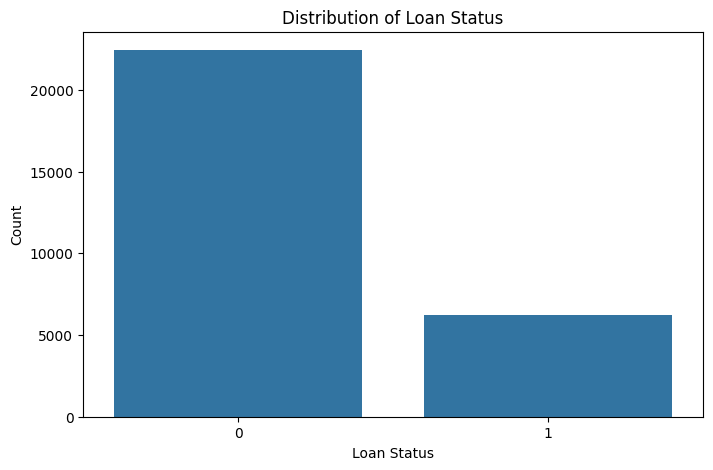

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="loan_status", data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()



- Majority of loans are not approved (0)
- Fewer loans are approved (1)

This shows class imbalance in the dataset, which may affect model performance.

### Distribution of Loan Grade

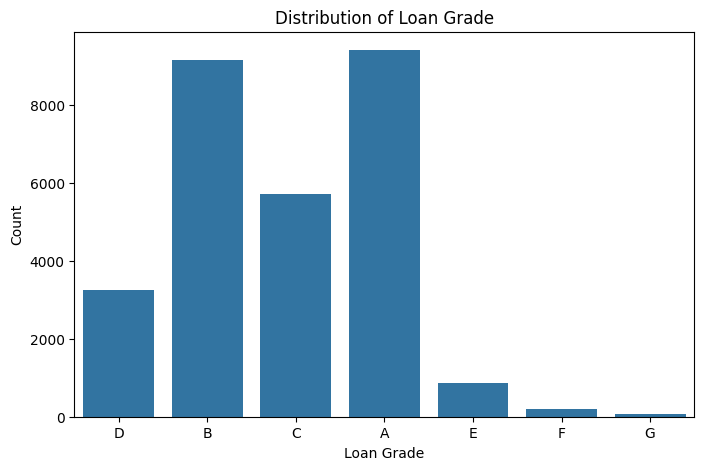

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x="loan_grade", data=df)
plt.title('Distribution of Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()

- Most loans fall under grades A, B, and C
- Very few loans are in high-risk categories like F and G

This indicates that most applicants are relatively low to medium risk.

### istribution of Loan Intent

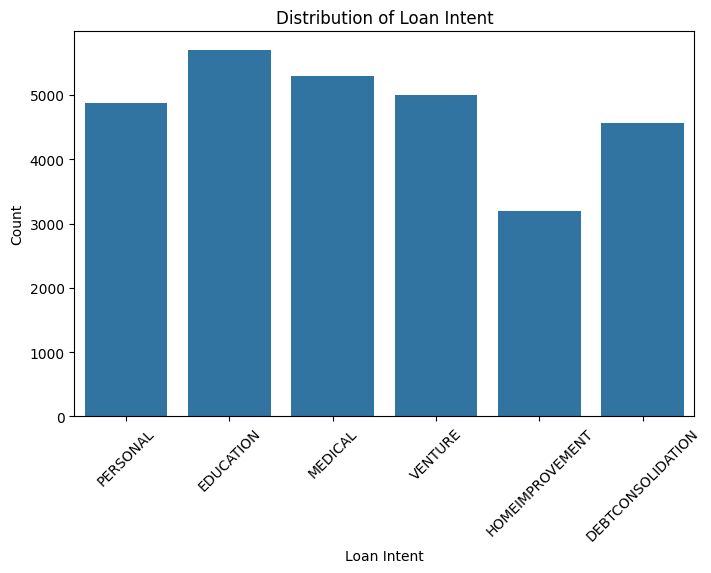

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x="loan_intent", data=df)
plt.title('Distribution of Loan Intent')
plt.xlabel('Loan Intent')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

- Most common purposes include:
   - Education
   - Medical
   - Venture 
- lest common:
    - Homeimprovement

This shows the primary reasons why people apply for loans.

### Distribution of Home Ownership

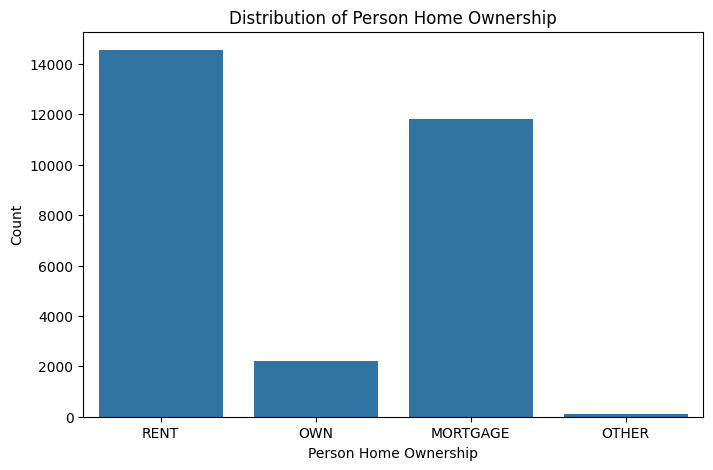

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x="person_home_ownership", data=df)
plt.title('Distribution of Person Home Ownership')
plt.xlabel('Person Home Ownership')
plt.ylabel('Count')
plt.show()

- Most applicants ether Rent or have their home on mortgage
- few applicants have their own home

This suggests that many applicants are financially dependent on housing loans or rent.

### Person Income vs Loan Amount (by Loan Status)

This scatter plot shows the relationship between applicant income and loan amount, categorized by loan status.

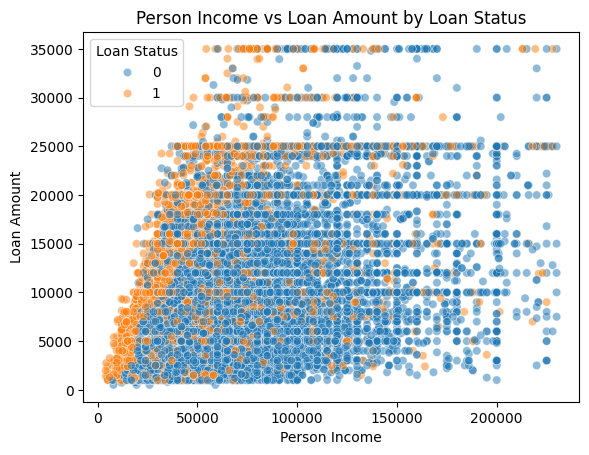

In [18]:
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=df, alpha=0.5)
plt.title('Person Income vs Loan Amount by Loan Status')
plt.xlabel('Person Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')
plt.show()


#### Key Observations:
- Most applicants fall in the low to mid income range (below 100,000)
- Loan amount generally increases with income (positive relationship)
- Approved (1) and not approved (0) loans are mixed across the plot
- Higher income does not guarantee loan approval
- Some applicants with lower income still receive loans, indicating other factors (like credit history) are important

#### Conclusion:
Income alone is not a strong predictor of loan approval. Other features such as credit history and loan percentage income play a more significant role.

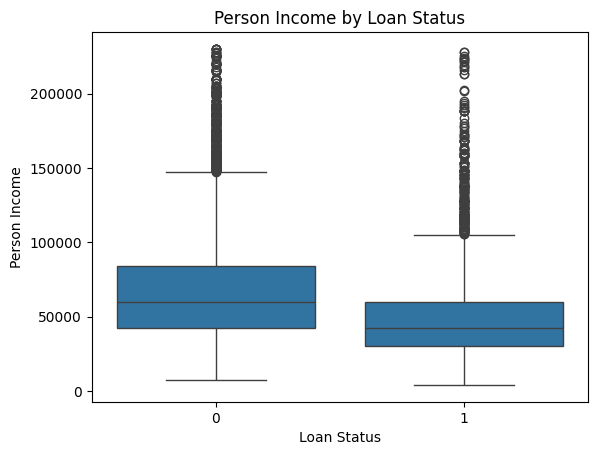

In [21]:
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title('Person Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Person Income')
plt.show()

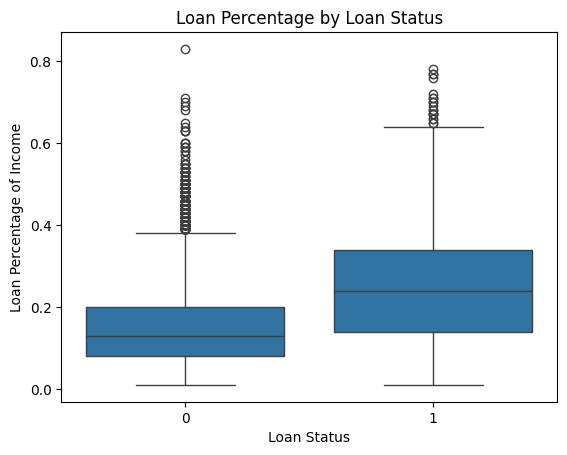

In [22]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title('Loan Percentage by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Percentage of Income')
plt.show()